#### PYTHON chạy trên version 3.13.3 visual studio code



**1.Cài đặt và sử dụng thư viện trực quan dữ liệu**

In [ ]:
pip install matplotlib seaborn
pip install pandas numpy
pip install scikit-learn

In [2]:
# Thư viện xử lý dữ liệu cơ bản
import pandas as pd
import numpy as np
# Thư viện trực quan hóa dữ liệu
import matplotlib.pyplot as plt
import seaborn as sns



**2.Làm sạch dữ liệu và tiền xử lý dữ liệu**

In [3]:
# Đọc dữ liệu
df = pd.read_csv("Sample - Superstore.csv", encoding='latin-1')
# Kiểm tra dữ liệu thiếu
print("\n Số lượng giá trị thiếu theo cột:")
print(df.isnull().sum())
# Đếm số dòng trùng lặp hoàn toàn (mọi cột)
duplicate_count = df.duplicated().sum()
print("Số dòng trùng lặp hoàn toàn:",duplicate_count)



 Số lượng giá trị thiếu theo cột:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
Số dòng trùng lặp hoàn toàn: 0


In [4]:
#Chuyển đổi kiểu dữ liệu thành datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])
#Tạo các cột mới 
df['Order Year'] = df['Order Date'].dt.year
df['Day of Week'] = df['Order Date'].dt.day_name()



#### Chuyển kiểu dữ liệu cột Order Date sang dạng datetime.
#### Tạo thêm cột mới:

- Order Year: năm của ngày đặt hàng.

- Day of Week: thứ trong tuần của ngày đặt hàng.



**3. Phân tích và trực quan hóa dữ liệu Số lượng đơn hàng theo Thứ trong tuần và Năm**

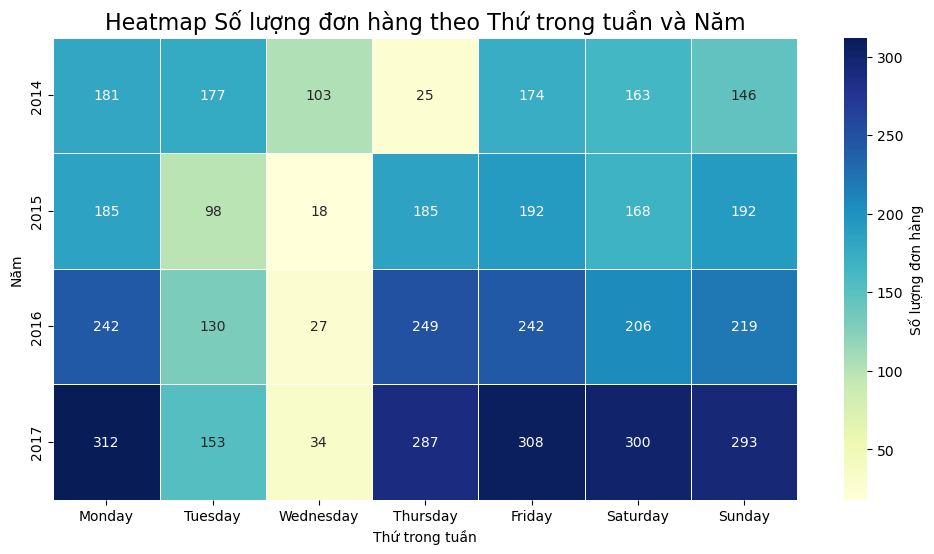

In [5]:
# Heatmap Số lượng đơn hàng theo Thứ trong tuần và Năm
# Index: Năm, Columns: Thứ trong tuần, Values: Số lượng đơn hàng
dfplot_orders_weekday_yearly = pd.pivot_table(
    data=df,
    index='Order Year',
    columns='Day of Week',
    values='Order ID',
    aggfunc='nunique'
).round(0)
# Sắp xếp lại thứ tự các ngày trong tuần 
ordered_weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dfplot_orders_weekday_yearly = dfplot_orders_weekday_yearly[ordered_weekdays]
# Vẽ biểu đồ  
plt.figure(figsize=(12, 6))
sns.heatmap(dfplot_orders_weekday_yearly, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5, cbar_kws={'label': 'Số lượng đơn hàng'})
plt.title('Heatmap Số lượng đơn hàng theo Thứ trong tuần và Năm', fontsize=16)
plt.xlabel('Thứ trong tuần')
plt.ylabel('Năm')
plt.show()

- Biểu đồ heatmap cho thấy số lượng đơn hàng tăng dần theo từng năm, đặc biệt rõ rệt trong năm 2017.
- Thứ Tư luôn là ngày có ít đơn hàng nhất, trong khi Thứ Sáu và Cuối tuần (Thứ Bảy, Chủ Nhật) thường có số đơn hàng cao nhất.
→ Xu hướng mua sắm tăng mạnh vào cuối tuần và cải thiện đáng kể qua các năm.

#### Đề xuất
- Tối ưu hóa cuối tuần: Tăng cường nhân sự và dịch vụ để đáp ứng lượng đơn hàng lớn vào cuối tuần.

- Kích cầu thứ Tư: Đẩy mạnh các chương trình khuyến mãi, ưu đãi để tăng doanh số vào ngày thấp điểm.

- Xây dựng chiến lược dài hạn: Phân tích xu hướng tăng trưởng qua các năm để xây dựng kế hoạch kinh doanh cho tương lai.

**4. Xây dựng mô hình Machine Learning — Logistic Regression dự đoán đơn hàng Lãi / Lỗ**



Khởi tạo & import

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

Lựa chọn features đầu vào

In [7]:
# Tạo nhãn nhị phân: lãi (1) / lỗ (0)
df["Profit_Positive"] = (df["Profit"] > 0).astype(int)

# Chọn features cơ bản
X = df[["Sales", "Discount", "Quantity"]]
y = df["Profit_Positive"]

# Tách train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


Train Logistic Regression- Đánh giá mô hình

In [8]:
# Train Logistic Regression
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

# Đánh giá
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.65      0.78       484
           1       0.92      1.00      0.96      2015

    accuracy                           0.93      2499
   macro avg       0.95      0.82      0.87      2499
weighted avg       0.93      0.93      0.92      2499



Lớp 0 = đơn hàng lỗ (Profit ≤ 0)

precision 0.98: khi model dự đoán “lỗ” thì ~98% đúng

recall 0.65: nhưng chỉ bắt được ~65% các ca thật sự lỗ → bỏ sót 35% (dự đoán nhầm thành lãi)

Lớp 1 = đơn hàng lãi (Profit > 0)

precision 0.92, recall 1.00: gần như không bỏ sót ca lãi

Support cho thấy dữ liệu lệch lớp (2015 lãi vs 484 lỗ). Vì lệch, model nghiêng về dự đoán “lãi”, nên recall lớp 0 thấp.

In [9]:
# Thử dự đoán 1 dòng mới
new_sample = pd.DataFrame({"Sales":[500], "Discount":[0.2], "Quantity":[3]})
print("Predict new_sample (1=lãi, 0=lỗ):", model.predict(new_sample)[0])

Predict new_sample (1=lãi, 0=lỗ): 1


Một order có 500$ Sales, Discount 20%, Quantity 3 → dự đoán LÃI